# Framingham Heart Study — Causal Analysis with CausalPype

**Research question:** *What are the causal determinants of 10-year coronary heart disease (CHD) risk?*

The [Framingham Heart Study](https://www.framinghamheartstudy.org/) is one of the most influential longitudinal cardiovascular studies, running since 1948. This teaching dataset contains 4,240 participants with 15 risk factors and a binary 10-year CHD outcome.

We use **CausalPype** to:
1. Define a causal DAG from cardiovascular epidemiology domain knowledge
2. Fit a structural causal model (SCM) to the data
3. Run a comprehensive set of causal experiments: treatment effects, interventions, counterfactuals, fairness audits, and more

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, IterativeImputer

import causalpype as cp
from causalpype import (
    ATE, CATE, Intervention, Counterfactual,
    ArrowStrength, IntrinsicCausalInfluence,
    CausalEffectCurve, FairnessAudit,
    KNNIntervention, StochasticIntervention,
    AnomalyAttribution, DistributionChange, Validate,
)

## 1. Load Data

In [2]:
df = pd.read_csv("data/framingham.csv")
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (4240, 16)

Column types:
male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

First 5 rows:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 2. Exploratory Data Analysis

In [3]:
# Descriptive statistics
print("Descriptive statistics:")
print(df.describe().round(2).to_string())

print(f"\nOutcome prevalence: {df['TenYearCHD'].mean():.1%} developed CHD within 10 years")

Descriptive statistics:
          male      age  education  currentSmoker  cigsPerDay   BPMeds  prevalentStroke  prevalentHyp  diabetes  totChol    sysBP    diaBP      BMI  heartRate  glucose  TenYearCHD
count  4240.00  4240.00    4135.00        4240.00     4211.00  4187.00          4240.00       4240.00   4240.00  4190.00  4240.00  4240.00  4221.00    4239.00  3852.00     4240.00
mean      0.43    49.58       1.98           0.49        9.01     0.03             0.01          0.31      0.03   236.70   132.35    82.90    25.80      75.88    81.96        0.15
std       0.50     8.57       1.02           0.50       11.92     0.17             0.08          0.46      0.16    44.59    22.03    11.91     4.08      12.03    23.95        0.36
min       0.00    32.00       1.00           0.00        0.00     0.00             0.00          0.00      0.00   107.00    83.50    48.00    15.54      44.00    40.00        0.00
25%       0.00    42.00       1.00           0.00        0.00     0.00      

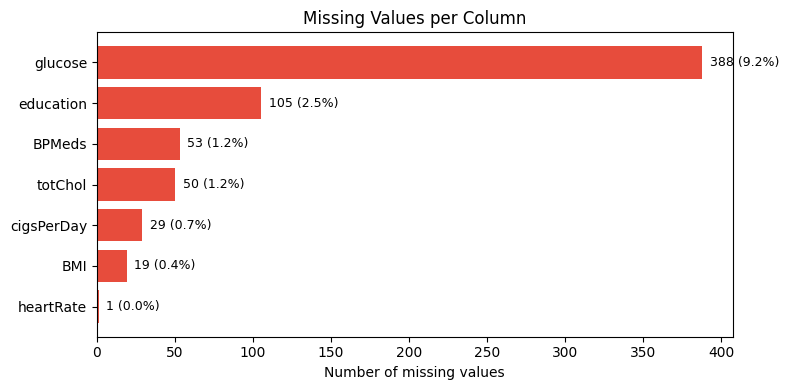

In [4]:
# Missingness audit
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing.index, missing.values, color="#e74c3c")
for bar, val in zip(bars, missing.values):
    pct = val / len(df) * 100
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{val} ({pct:.1f}%)", va="center", fontsize=9)
ax.set_xlabel("Number of missing values")
ax.set_title("Missing Values per Column")
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

**Strategy:**
- **Categoricals** (male, education, currentSmoker, BPMeds, prevalentStroke, prevalentHyp, diabetes, TenYearCHD): mode imputation
- **Continuous** (age, cigsPerDay, totChol, sysBP, diaBP, BMI, heartRate, glucose): MICE imputation

In [5]:
cat_cols = ["male", "education", "currentSmoker", "BPMeds",
            "prevalentStroke", "prevalentHyp", "diabetes"]
# Note: TenYearCHD is kept as numeric (not category) for compatibility
# with counterfactual subtraction operations
cont_cols = [c for c in df.columns if c not in cat_cols and c != "TenYearCHD"]

print("Categorical columns and their distributions:")
for col in cat_cols:
    vals = df[col].dropna()
    print(f"  {col}: {vals.nunique()} categories, missing={df[col].isna().sum()}")

# Phase 1: Mode imputation for categoricals
impute_cats = cat_cols.copy()
cat_imputer = SimpleImputer(strategy="most_frequent")
df[impute_cats] = cat_imputer.fit_transform(df[impute_cats])

# Phase 2: MICE for continuous variables
df_for_mice = df.copy()
for col in cat_cols:
    df_for_mice[col] = df_for_mice[col].astype(float)

mice = IterativeImputer(max_iter=20, random_state=42, sample_posterior=False)
imputed = pd.DataFrame(
    mice.fit_transform(df_for_mice),
    columns=df_for_mice.columns,
    index=df_for_mice.index,
)

for col in cont_cols:
    df[col] = imputed[col].values

# Convert categoricals to category dtype (required by DoWhy auto mechanism assignment)
for col in cat_cols:
    df[col] = df[col].astype(int).astype("category")

# Verify
assert df.isna().sum().sum() == 0, "Still have missing values!"
print(f"\nAll missing values imputed. Final shape: {df.shape}")
print(f"\nContinuous variable stats after imputation:")
print(df[cont_cols].describe().round(2).to_string())

Categorical columns and their distributions:
  male: 2 categories, missing=0
  education: 4 categories, missing=105
  currentSmoker: 2 categories, missing=0
  BPMeds: 2 categories, missing=53
  prevalentStroke: 2 categories, missing=0
  prevalentHyp: 2 categories, missing=0
  diabetes: 2 categories, missing=0

All missing values imputed. Final shape: (4240, 16)

Continuous variable stats after imputation:
           age  cigsPerDay  totChol    sysBP    diaBP      BMI  heartRate  glucose
count  4240.00     4240.00  4240.00  4240.00  4240.00  4240.00    4240.00  4240.00
mean     49.58        9.07   236.75   132.35    82.90    25.80      75.88    81.82
std       8.57       11.91    44.36    22.03    11.91     4.07      12.02    23.01
min      32.00        0.00   107.00    83.50    48.00    15.54      44.00    40.00
25%      42.00        0.00   206.00   117.00    75.00    23.07      68.00    72.00
50%      49.00        0.00   234.00   128.00    82.00    25.38      75.00    78.00
75%      5

In [6]:
# Plausibility checks
checks = {
    "age": (20, 80, "years"),
    "cigsPerDay": (0, 80, "cigs"),
    "totChol": (100, 600, "mg/dL"),
    "sysBP": (60, 300, "mmHg"),
    "diaBP": (40, 200, "mmHg"),
    "BMI": (10, 60, "kg/m²"),
    "heartRate": (30, 200, "bpm"),
    "glucose": (30, 500, "mg/dL"),
}
print("Plausibility checks:")
for col, (lo, hi, unit) in checks.items():
    vals = df[col]
    issues = []
    if (vals < lo).any():
        issues.append(f"{(vals < lo).sum()} below {lo}")
    if (vals > hi).any():
        issues.append(f"{(vals > hi).sum()} above {hi}")
    status = ", ".join(issues) if issues else "OK"
    print(f"  {col:15s} [{lo}-{hi} {unit}]: {status}")

Plausibility checks:
  age             [20-80 years]: OK
  cigsPerDay      [0-80 cigs]: OK
  totChol         [100-600 mg/dL]: 1 above 600
  sysBP           [60-300 mmHg]: OK
  diaBP           [40-200 mmHg]: OK
  BMI             [10-60 kg/m²]: OK
  heartRate       [30-200 bpm]: OK
  glucose         [30-500 mg/dL]: OK


## 4. Causal Graph Definition

We construct a DAG from well-established cardiovascular epidemiology knowledge:

- **Demographics** (age, male) influence blood pressure, cholesterol, BMI, and CHD directly
- **Education** influences smoking behavior
- **BMI** mediates effects on blood pressure, cholesterol, glucose, and diabetes
- **Blood pressure** leads to hypertension diagnosis and treatment
- **Glucose** drives diabetes
- **All major risk factors** have direct paths to 10-year CHD

> **Note:** In reality, BP medication lowers systolic BP, creating a feedback loop (`sysBP → prevalentHyp → BPMeds → sysBP`). Since DAGs cannot represent cycles, we drop the `BPMeds → sysBP` edge — in a cross-sectional snapshot, BPMeds reflects treatment *response*, not a cause of current BP.

In [7]:
# Define causal graph from domain knowledge
adj = {
    "age":            ["sysBP", "diaBP", "totChol", "glucose", "BMI", "heartRate", "TenYearCHD"],
    "male":           ["sysBP", "diaBP", "totChol", "BMI", "heartRate", "currentSmoker", "TenYearCHD"],
    "education":      ["currentSmoker"],
    "currentSmoker":  ["cigsPerDay"],
    "cigsPerDay":     ["heartRate", "TenYearCHD"],
    "BMI":            ["sysBP", "diaBP", "totChol", "glucose", "diabetes", "TenYearCHD"],
    "sysBP":          ["prevalentHyp", "TenYearCHD"],
    "diaBP":          ["prevalentHyp"],
    "prevalentHyp":   ["BPMeds"],
    "glucose":        ["diabetes"],
    "diabetes":       ["TenYearCHD"],
    "totChol":        ["TenYearCHD"],
    "heartRate":      ["TenYearCHD"],
    "prevalentStroke": ["TenYearCHD"],
}

G = nx.DiGraph(adj)
assert nx.is_directed_acyclic_graph(G), "Graph contains cycles!"

roots = [n for n in G.nodes if G.in_degree(n) == 0]
leaves = [n for n in G.nodes if G.out_degree(n) == 0]
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
print(f"Root (exogenous) nodes: {roots}")
print(f"Leaf nodes: {leaves}")

Nodes: 16, Edges: 33
Root (exogenous) nodes: ['age', 'male', 'education', 'prevalentStroke']
Leaf nodes: ['TenYearCHD', 'BPMeds']


## 5. Model Creation & Fitting

In [8]:
model = cp.CausalModel(G)
print(model)

CausalModel(not fitted, nodes=['age', 'male', 'education', 'currentSmoker', 'cigsPerDay', 'BMI', 'sysBP', 'diaBP', 'prevalentHyp', 'glucose', 'diabetes', 'totChol', 'heartRate', 'prevalentStroke', 'TenYearCHD', 'BPMeds'], edges=[('age', 'sysBP'), ('age', 'diaBP'), ('age', 'totChol'), ('age', 'glucose'), ('age', 'BMI'), ('age', 'heartRate'), ('age', 'TenYearCHD'), ('male', 'sysBP'), ('male', 'diaBP'), ('male', 'totChol'), ('male', 'BMI'), ('male', 'heartRate'), ('male', 'currentSmoker'), ('male', 'TenYearCHD'), ('education', 'currentSmoker'), ('currentSmoker', 'cigsPerDay'), ('cigsPerDay', 'heartRate'), ('cigsPerDay', 'TenYearCHD'), ('BMI', 'sysBP'), ('BMI', 'diaBP'), ('BMI', 'totChol'), ('BMI', 'glucose'), ('BMI', 'diabetes'), ('BMI', 'TenYearCHD'), ('sysBP', 'prevalentHyp'), ('sysBP', 'TenYearCHD'), ('diaBP', 'prevalentHyp'), ('prevalentHyp', 'BPMeds'), ('glucose', 'diabetes'), ('diabetes', 'TenYearCHD'), ('totChol', 'TenYearCHD'), ('heartRate', 'TenYearCHD'), ('prevalentStroke', 'Ten

(<Figure size 1400x1000 with 1 Axes>, <Axes: title={'center': 'Causal Graph'}>)

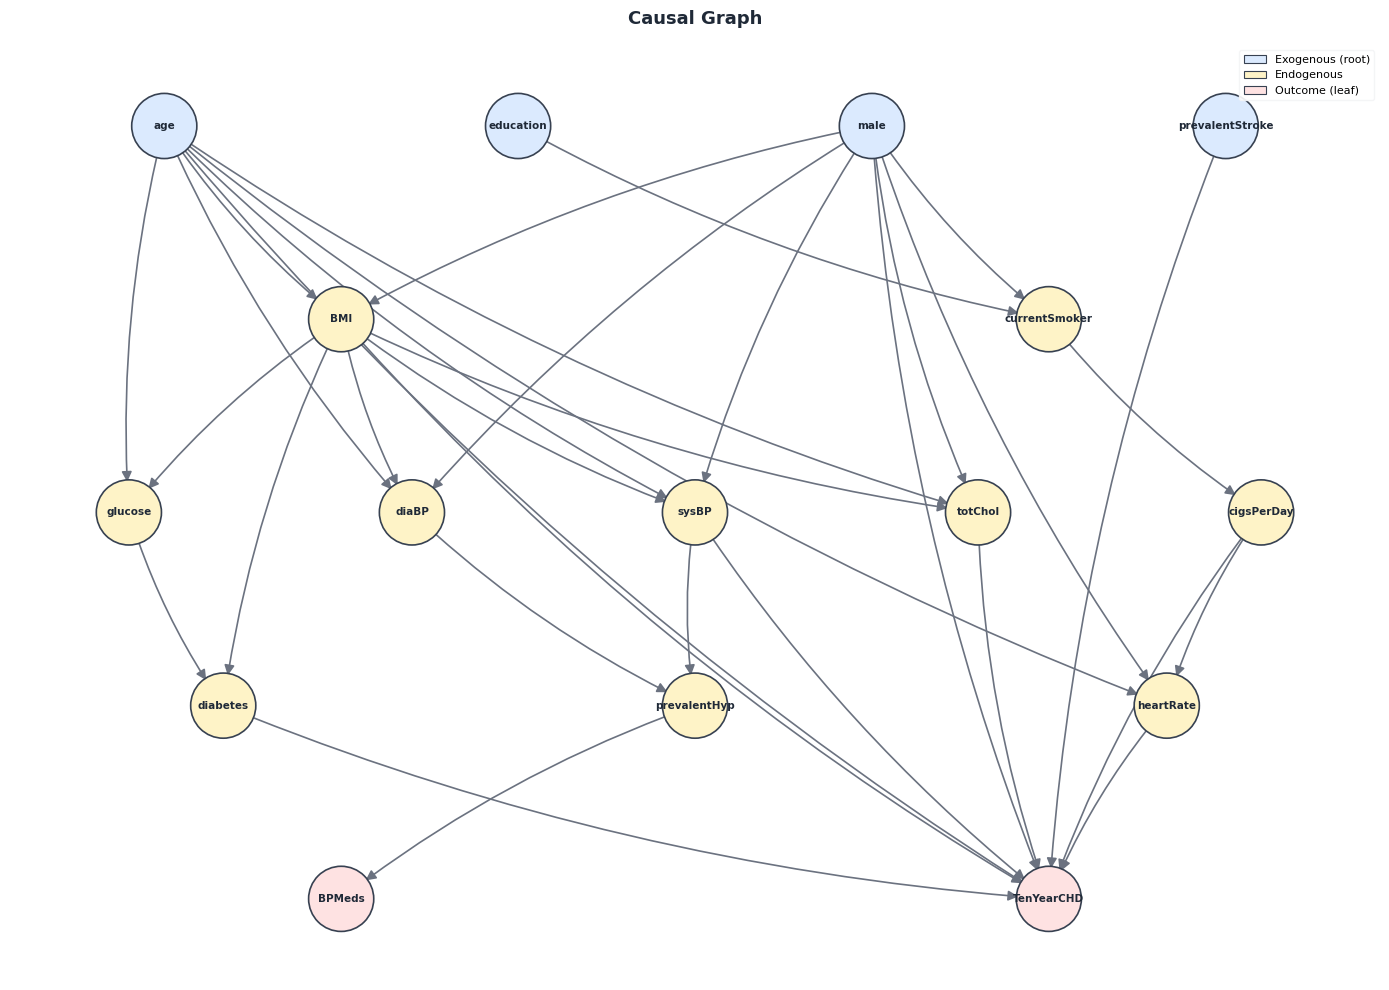

In [9]:
cp.plotting.plot_graph(model)

In [10]:
model.fit(df)
print(model)

print("\nAssigned causal mechanisms:")
for node in sorted(model.graph.nodes):
    mechanism = model.scm.causal_mechanism(node)
    mtype = type(mechanism).__name__
    print(f"  {node:20s} → {mtype}")

Fitting causal mechanism of node BPMeds: 100%|██████████| 16/16 [00:00<00:00, 51.19it/s]         

CausalModel(fitted, nodes=['age', 'male', 'education', 'currentSmoker', 'cigsPerDay', 'BMI', 'sysBP', 'diaBP', 'prevalentHyp', 'glucose', 'diabetes', 'totChol', 'heartRate', 'prevalentStroke', 'TenYearCHD', 'BPMeds'], edges=[('age', 'sysBP'), ('age', 'diaBP'), ('age', 'totChol'), ('age', 'glucose'), ('age', 'BMI'), ('age', 'heartRate'), ('age', 'TenYearCHD'), ('male', 'sysBP'), ('male', 'diaBP'), ('male', 'totChol'), ('male', 'BMI'), ('male', 'heartRate'), ('male', 'currentSmoker'), ('male', 'TenYearCHD'), ('education', 'currentSmoker'), ('currentSmoker', 'cigsPerDay'), ('cigsPerDay', 'heartRate'), ('cigsPerDay', 'TenYearCHD'), ('BMI', 'sysBP'), ('BMI', 'diaBP'), ('BMI', 'totChol'), ('BMI', 'glucose'), ('BMI', 'diabetes'), ('BMI', 'TenYearCHD'), ('sysBP', 'prevalentHyp'), ('sysBP', 'TenYearCHD'), ('diaBP', 'prevalentHyp'), ('prevalentHyp', 'BPMeds'), ('glucose', 'diabetes'), ('diabetes', 'TenYearCHD'), ('totChol', 'TenYearCHD'), ('heartRate', 'TenYearCHD'), ('prevalentStroke', 'TenYear

## 6. Model Validation

Check whether the data supports the conditional independence assumptions implied by our causal graph.

In [11]:
task = Validate(method="all", significance_level=0.05)
result = model.run(task)
result.summary()

╭──────────── Validation ────────────╮
│                                    │
│  Result: ISSUES FOUND              │
│                                    │
│  Structure                         │
│   Passed                ✗          │
│   N Tests               45         │
│   Bonferroni Level      ↑ 0.0011   │
│                                    │
│  Model                             │
│   Passed                ✗          │
│   Result                REJECTED   │
│                                    │
╰────────────────────────────────────╯

''

## 7. Causal Experiments

### 7.1 Arrow Strength — Which edges matter most for CHD?

Quantifies the KL-divergence contribution of each edge pointing into `TenYearCHD`.

In [12]:
task = ArrowStrength(target="TenYearCHD")
result_arrow = model.run(task)
result_arrow.summary()

╭──────────────────────────── Arrow Strength ─────────────────────────────╮
│                                                                         │
│  Estimate:                                                              │
│   Target                        TenYearCHD                              │
│   age -> TenYearCHD                ↑ 0.0019  ████████████████████       │
│   diabetes -> TenYearCHD           ↑ 0.0016  ████████████████           │
│   sysBP -> TenYearCHD              ↑ 0.0011  ████████████               │
│   male -> TenYearCHD               ↑ 0.0008  ████████                   │
│   cigsPerDay -> TenYearCHD         ↑ 0.0007  ███████                    │
│   BMI -> TenYearCHD                ↑ 0.0007  ███████                    │
│   totChol -> TenYearCHD           ↓ -0.0006  ██████                     │
│   prevalentStroke -> TenYearCHD    ↑ 0.0004  ████                       │
│   heartRate -> TenYearCHD          ↑ 0.0003  ██                         │
│                                                                         │
│  Raw Strengths                                                          │
│   ('age', 'TenYearCHD')                ↑ 0.0019  ████████████████████   │
│   ('diabetes', 'TenYearCHD')           ↑ 0.0016  ████████████████       │
│   ('sysBP', 'TenYearCHD')              ↑ 0.0011  ████████████           │
│   ('male', 'TenYearCHD')               ↑ 0.0008  ████████               │
│   ('cigsPerDay', 'TenYearCHD')         ↑ 0.0007  ███████                │
│   ('BMI', 'TenYearCHD')                ↑ 0.0007  ███████                │
│   ('totChol', 'TenYearCHD')           ↓ -0.0006  ██████                 │
│   ('prevalentStroke', 'TenYearCHD')    ↑ 0.0004  ████                   │
│   ('heartRate', 'TenYearCHD')          ↑ 0.0003  ██                     │
│                                                                         │
╰─────────────────────────────────────────────────────────────────────────╯

''

(<Figure size 1400x1000 with 1 Axes>, <Axes: title={'center': 'Causal Graph'}>)

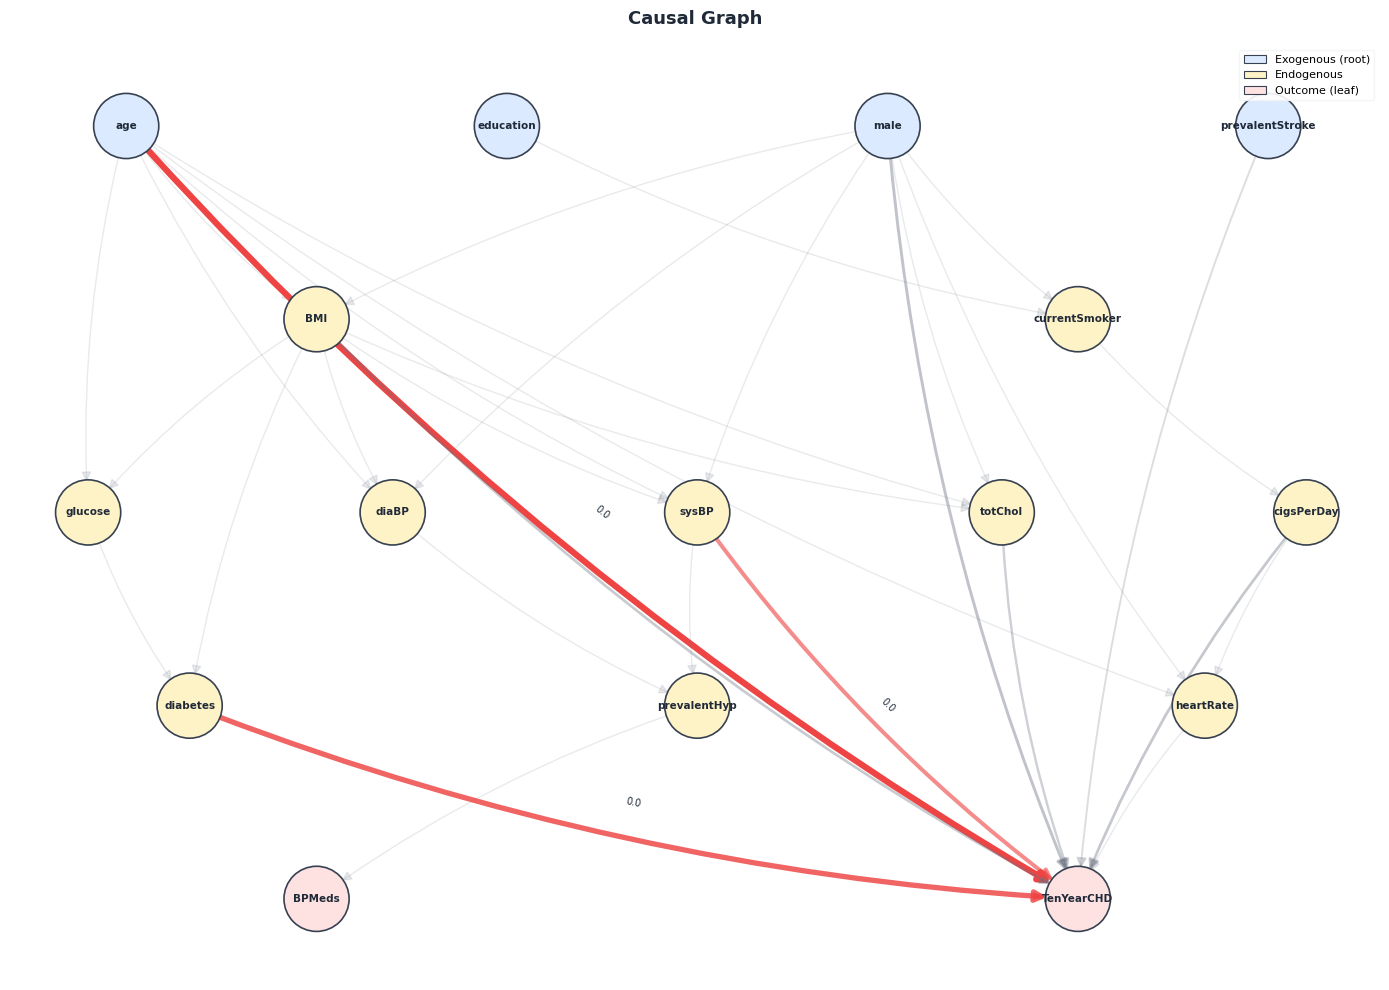

In [13]:
# Visualize DAG with arrow strengths
cp.plotting.plot_graph(model, strengths=result_arrow)

### 7.2 Intrinsic Causal Influence — Variance decomposition of CHD risk

Decomposes the variance in `TenYearCHD` across upstream noise terms using Shapley values.

In [14]:
task = IntrinsicCausalInfluence(target="TenYearCHD")
result_ici = model.run(task)
result_ici.summary()

Evaluating set functions...: 100%|██████████| 269/269 [00:22<00:00, 11.80it/s]


╭──────────────── Intrinsic Causal Influence ────────────────╮
│                                                            │
│  Estimate:                                                 │
│   Target                        TenYearCHD                 │
│   Total Variance Explained      ↑ 0.1196                   │
│   TenYearCHD              ↑ 0.1188  ████████████████████   │
│   age                     ↑ 0.0002                         │
│   sysBP                   ↑ 0.0002                         │
│   prevalentStroke         ↑ 0.0002                         │
│   male                    ↑ 0.0002                         │
│   cigsPerDay             ↓ -0.0001                         │
│   BMI                    ↓ -0.0000                         │
│   glucose                 ↑ 0.0000                         │
│   currentSmoker           ↑ 0.0000                         │
│   diabetes                ↑ 0.0000                         │
│   heartRate              ↓ -0.0000                         │
│   education              ↓ -0.0000                         │
│   totChol                 ↑ 0.0000                         │
│                                                            │
│  Normalized                                                │
│   TenYearCHD              ↑ 0.9935  ████████████████████   │
│   age                     ↑ 0.0019                         │
│   sysBP                   ↑ 0.0019                         │
│   prevalentStroke         ↑ 0.0017                         │
│   male                    ↑ 0.0013                         │
│   cigsPerDay             ↓ -0.0005                         │
│   BMI                    ↓ -0.0004                         │
│   glucose                 ↑ 0.0003                         │
│   currentSmoker           ↑ 0.0003                         │
│   diabetes                ↑ 0.0002                         │
│   heartRate              ↓ -0.0001                         │
│   education              ↓ -0.0001                         │
│   totChol                 ↑ 0.0000                         │
│                                                            │
╰────────────────────────────────────────────────────────────╯

''

(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Intrinsic Causal Influence on ‘TenYearCHD’'}, xlabel='Proportion of Variance Explained'>)

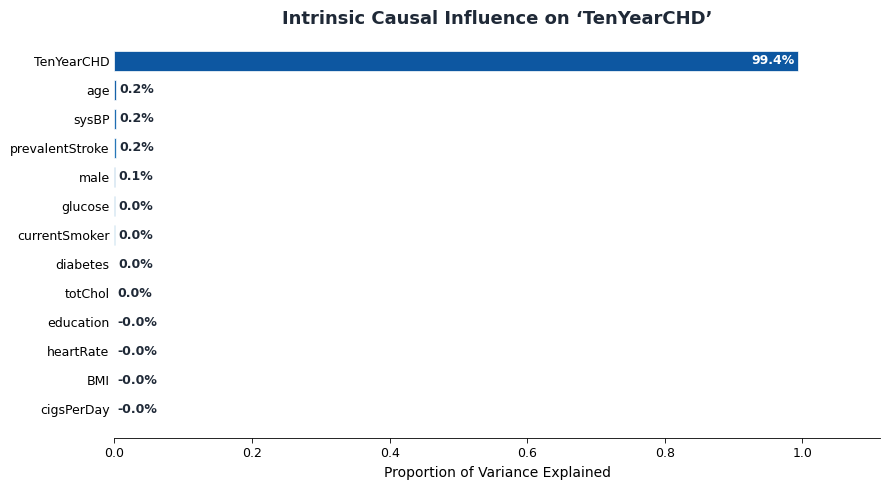

In [15]:
cp.plotting.plot_influences(result_ici)

### 7.3 Average Treatment Effect (ATE) — Does smoking cause CHD?

Estimate the average causal effect of being a current smoker on 10-year CHD risk.

In [16]:
task = ATE(
    treatment="currentSmoker",
    treatment_value=1,
    control_value=0,
    outcome="TenYearCHD",
)
result_ate = model.run(task)
result_ate.summary()

╭────────────────────── ATE ──────────────────────╮
│                                                 │
│  Estimate: ↑ 0.0295                             │
│   Treatment                     currentSmoker   │
│   Outcome                       TenYearCHD      │
│   Treatment Value               1               │
│   Control Value                 0               │
│   Num Samples                   2,000           │
│                                                 │
╰─────────────────────────────────────────────────╯

''

### 7.4 Conditional ATE (CATE) — Heterogeneous smoking effects

Does the causal effect of smoking on CHD vary across patient subgroups (by age and sex)?

In [17]:
task = CATE(
    treatment="currentSmoker",
    outcome="TenYearCHD",
    effect_modifiers=["age", "male", "BMI", "sysBP"],
    method="linear_dml",
)
result_cate = model.run(task)
result_cate.summary()

╭───────────────────────── CATE ──────────────────────────╮
│                                                         │
│  Estimate: ↑ 0.0434                                     │
│   Treatment                     currentSmoker           │
│   Outcome                       TenYearCHD              │
│   Effect Modifiers              age, male, BMI, sysBP   │
│   Method                        linear_dml              │
│   Mean Effect                   ↑ 0.0434                │
│   STD Effect                    ↑ 0.0281                │
│   Bounds                        ↓ -0.0225, ↑ 0.1461     │
│                                                         │
╰─────────────────────────────────────────────────────────╯

''

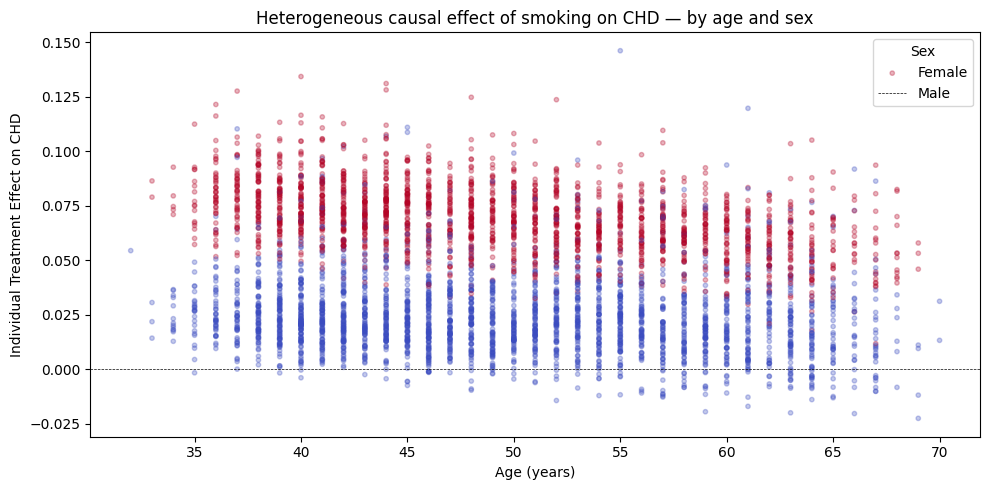

In [18]:
# Visualize individual treatment effects by age and sex
effects = result_cate.details["individual_effects"].flatten()

fig, ax = plt.subplots(figsize=(10, 5))
male_codes = df["male"].cat.codes.values
scatter = ax.scatter(df["age"], effects, c=male_codes, cmap="coolwarm", alpha=0.3, s=10)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Individual Treatment Effect on CHD")
ax.set_title("Heterogeneous causal effect of smoking on CHD — by age and sex")
ax.legend(*scatter.legend_elements(), labels=["Female", "Male"], title="Sex")
plt.tight_layout()
plt.show()

### 7.5 Intervention — What if everyone had a healthy BMI?

Compare CHD risk under no intervention vs. a policy where everyone's BMI is set to 23 (normal weight).

Baseline CHD risk:  0.1498
Policy CHD risk:    0.1506
Risk reduction:     -0.0008


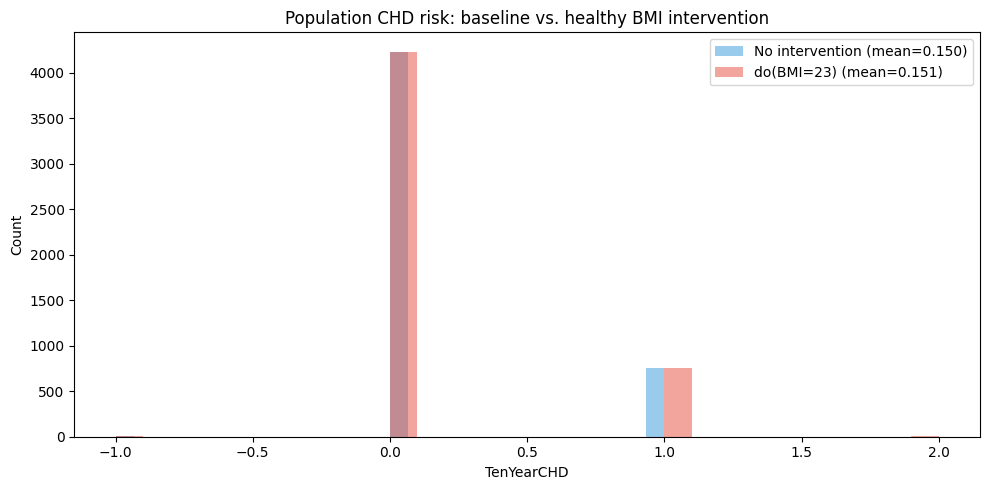

In [19]:
result_baseline = model.run(Intervention(
    interventions={},
    outcome="TenYearCHD",
    num_samples=5000,
))

result_policy = model.run(Intervention(
    interventions={"BMI": 23.0},
    outcome="TenYearCHD",
    num_samples=5000,
))

print(f"Baseline CHD risk:  {result_baseline.estimate:.4f}")
print(f"Policy CHD risk:    {result_policy.estimate:.4f}")
print(f"Risk reduction:     {result_baseline.estimate - result_policy.estimate:+.4f}")

# Overlaid histograms
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(result_baseline.details["samples"]["TenYearCHD"], bins=30, alpha=0.5,
        label=f"No intervention (mean={result_baseline.estimate:.3f})", color="#3498db")
ax.hist(result_policy.details["samples"]["TenYearCHD"], bins=30, alpha=0.5,
        label=f"do(BMI=23) (mean={result_policy.estimate:.3f})", color="#e74c3c")
ax.set_xlabel("TenYearCHD")
ax.set_ylabel("Count")
ax.set_title("Population CHD risk: baseline vs. healthy BMI intervention")
ax.legend()
plt.tight_layout()
plt.show()

### 7.6 Counterfactual — What if smokers had quit?

For patients who developed CHD and were smokers: what would their outcome have been if they had never smoked?

In [20]:
# Select smokers who developed CHD
smokers_chd = df[(df["currentSmoker"] == 1) & (df["TenYearCHD"] == 1)].copy()
print(f"Smokers who developed CHD: {len(smokers_chd)}")

task = Counterfactual(
    interventions={"currentSmoker": 0, "cigsPerDay": 0},
    observed_data=smokers_chd,
    outcome="TenYearCHD",
)
result_cf = model.run(task)
result_cf.summary()

Smokers who developed CHD: 333


╭────────────────────── Counterfactual ──────────────────────╮
│                                                            │
│  Estimate: ↑ 0.9970                                        │
│   N Units                       333                        │
│   Outcome                       TenYearCHD                 │
│   Factual Mean                  ↑ 1.0000                   │
│   Counterfactual Mean           ↑ 0.9970                   │
│   Mean Effect                   ↓ -0.0030                  │
│                                                            │
│  Interventions                                             │
│   currentSmoker                  0                         │
│   cigsPerDay                     0                         │
│                                                            │
╰────────────────────────────────────────────────────────────╯

''

### 7.7 Causal Effect Curve — Dose-response: BMI → CHD

How does the expected CHD risk change as BMI varies across a range of values?

╭──────────────────── Causal Effect Curve ────────────────────╮
│                                                             │
│  Estimate:     treatment_value  expected_outcome       std  │
│  0         15.540000            0.1450  0.356336            │
│  1         18.487143            0.1505  0.363111            │
│  2         21.434286            0.1525  0.362276            │
│  3         24.381429            0.1530  0.362755            │
│  4         27.328571            0.1535  0.361853            │
│  5         30.275714            0.1535  0.367339            │
│  6         33.222857            0.1630  0.373405            │
│  7         36.170000            0.1605  0.372478            │
│  8         39.117143            0.1495  0.362146            │
│  9         42.064286            0.1565  0.376839            │
│  10        45.011429            0.1460  0.358726            │
│  11        47.958571            0.1725  0.394644            │
│  12        50.905714            0.1585  0.370645            │
│  13        53.852857            0.1905  0.410134            │
│  14        56.800000            0.2020  0.424495            │
│   Treatment                     BMI                         │
│   Outcome                       TenYearCHD                  │
│                                                             │
│  Responses                                                  │
│   Treatment Value  Expected Outcome       STD               │
│         ↑ 15.5400          ↑ 0.1450  ↑ 0.3563               │
│         ↑ 18.4871          ↑ 0.1505  ↑ 0.3631               │
│         ↑ 21.4343          ↑ 0.1525  ↑ 0.3623               │
│         ↑ 24.3814          ↑ 0.1530  ↑ 0.3628               │
│         ↑ 27.3286          ↑ 0.1535  ↑ 0.3619               │
│               ...               ...       ...               │
│         ↑ 45.0114          ↑ 0.1460  ↑ 0.3587               │
│         ↑ 47.9586          ↑ 0.1725  ↑ 0.3946               │
│         ↑ 50.9057          ↑ 0.1585  ↑ 0.3706               │
│         ↑ 53.8529          ↑ 0.1905  ↑ 0.4101               │
│         ↑ 56.8000          ↑ 0.2020  ↑ 0.4245               │
│                                                             │
╰─────────────────────────────────────────────────────────────╯

(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Causal Effect Curve: BMI → TenYearCHD'}, xlabel='do(BMI)', ylabel='E[TenYearCHD]'>)

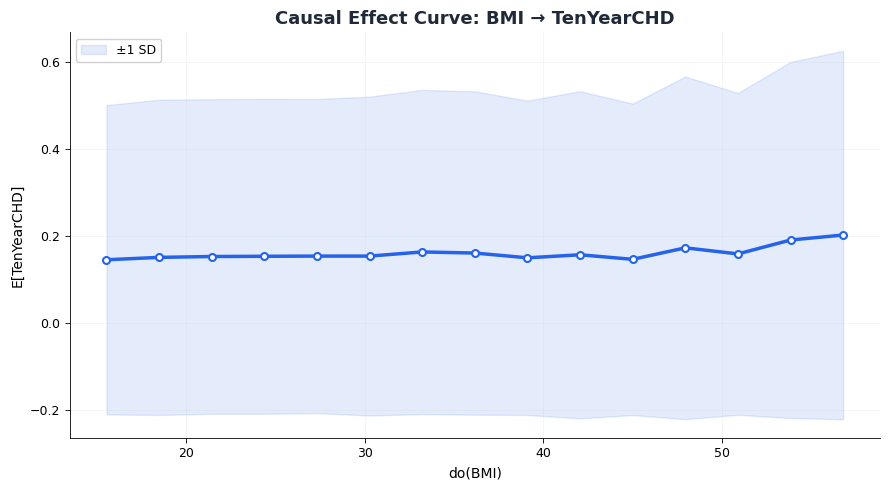

In [21]:
task = CausalEffectCurve(
    treatment="BMI",
    outcome="TenYearCHD",
    n_points=15,
    num_samples=2000,
)
result_curve = model.run(task)
result_curve.summary()

cp.plotting.plot_causal_effect_curve(result_curve)

### 7.8 Fairness Audit — Sex-based disparity in CHD risk

Is there a counterfactual disparity in CHD risk between males and females? How much of the observed gap is causally attributable to sex itself vs. mediated through other factors?

In [22]:
task = FairnessAudit(
    protected_attribute="male",
    outcome="TenYearCHD",
    privileged_value=1,      # male
    unprivileged_value=0,    # female
)
result_fair = model.run(task)
result_fair.summary()

obs_gap = result_fair.details["observational_gap"]
cf_gap = result_fair.details["counterfactual_disparity"]
print(f"\nObserved gap (male - female):       {obs_gap:+.4f}")
print(f"Counterfactual disparity (direct):  {cf_gap:+.4f}")
print(f"Mediated portion:                   {obs_gap - cf_gap:+.4f}")

╭─────────────── Fairness Audit ───────────────╮
│                                              │
│  Estimate: ↑ 0.0050                          │
│   Protected Attribute           male         │
│   Outcome                       TenYearCHD   │
│   Counterfactual Disparity      ↑ 0.0050     │
│   Observational Gap             ↑ 0.0641     │
│   Mean Individual Unfairness    ↑ 0.0050     │
│   Max Individual Unfairness     ↑ 1.0000     │
│   N Privileged                  1,820        │
│   N Unprivileged                2,420        │
│                                              │
╰──────────────────────────────────────────────╯


Observed gap (male - female):       +0.0641
Counterfactual disparity (direct):  +0.0050
Mediated portion:                   +0.0591


### 7.9 Stochastic Intervention — Sensitivity: reducing cholesterol

What if we could reduce everyone's total cholesterol by various amounts? How sensitive is CHD risk to cholesterol reduction?

  Shift   -10 mg/dL → E[CHD] = -0.0007
  Shift   -20 mg/dL → E[CHD] = 0.0057
  Shift   -30 mg/dL → E[CHD] = 0.0157
  Shift   -50 mg/dL → E[CHD] = -0.0020
  Shift   -70 mg/dL → E[CHD] = 0.0007


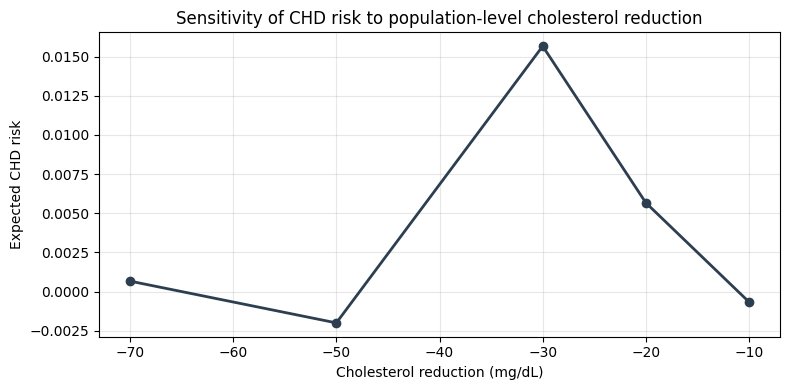

In [23]:
shifts = [-10, -20, -30, -50, -70]
results_stoch = []

for s in shifts:
    task = StochasticIntervention(
        treatment="totChol",
        outcome="TenYearCHD",
        shift=s,
        num_samples=3000,
    )
    res = model.run(task)
    results_stoch.append((s, res.estimate))
    print(f"  Shift {s:+5d} mg/dL → E[CHD] = {res.estimate:.4f}")

# Plot sensitivity curve
fig, ax = plt.subplots(figsize=(8, 4))
shifts_vals, estimates = zip(*results_stoch)
ax.plot(shifts_vals, estimates, "o-", color="#2c3e50", linewidth=2)
ax.set_xlabel("Cholesterol reduction (mg/dL)")
ax.set_ylabel("Expected CHD risk")
ax.set_title("Sensitivity of CHD risk to population-level cholesterol reduction")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.10 Distribution Change — Why does CHD differ between young and old?

Attribute the distribution shift in CHD risk from young (&lt;45) to older (≥55) participants to specific nodes in the causal graph.

Young (<45): 1427 participants, CHD rate: 6.4%
Old (>=55):  1317 participants, CHD rate: 25.0%


Evaluating set functions...: 100%|██████████| 267/267 [00:02<00:00, 105.39it/s]


╭─────────────────── Distribution Change ────────────────────╮
│                                                            │
│  Estimate:                                                 │
│   Target                        TenYearCHD                 │
│   N Old                         1,427                      │
│   N New                         1,317                      │
│   BMI                       0.0000                         │
│   TenYearCHD                0.0000                         │
│   age                       0.0000                         │
│   cigsPerDay                0.0000                         │
│   currentSmoker             0.0000                         │
│   diabetes                  0.0000                         │
│   education                 0.0000                         │
│   glucose                   0.0000                         │
│   heartRate                 0.0000                         │
│   male                      0.0000                         │
│   prevalentStroke           0.0000                         │
│   sysBP                     0.0000                         │
│   totChol                   0.0000                         │
│                                                            │
╰────────────────────────────────────────────────────────────╯

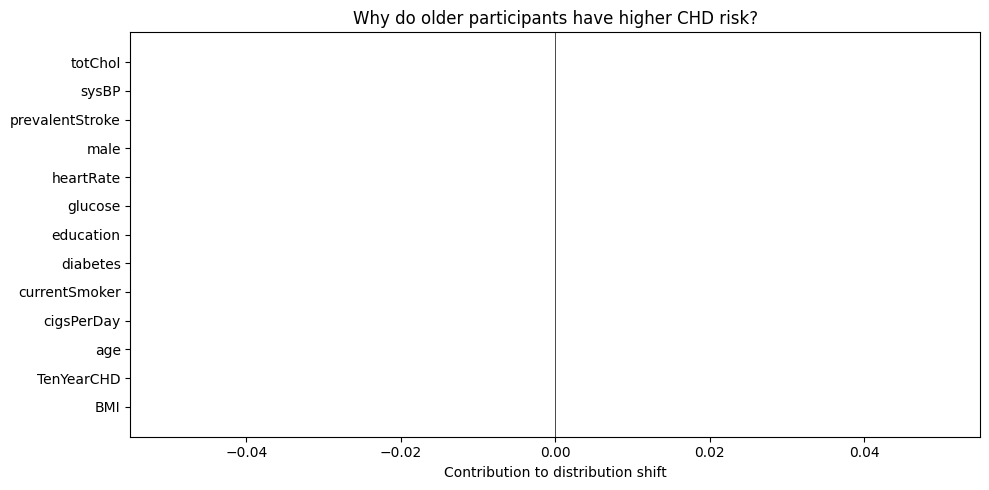

In [24]:
young = df[df["age"] < 45].copy()
old = df[df["age"] >= 55].copy()
print(f"Young (<45): {len(young)} participants, CHD rate: {young['TenYearCHD'].mean():.1%}")
print(f"Old (>=55):  {len(old)} participants, CHD rate: {old['TenYearCHD'].mean():.1%}")

task = DistributionChange(
    target="TenYearCHD",
    old_data=young,
    new_data=old,
    num_samples=3000,
)
result_dc = model.run(task)
result_dc.summary()

# Visualize contributions
contribs = result_dc.details["contributions"]
contribs_sorted = dict(sorted(contribs.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in contribs_sorted.values()]
ax.barh(list(contribs_sorted.keys()), list(contribs_sorted.values()), color=colors)
ax.set_xlabel("Contribution to distribution shift")
ax.set_title("Why do older participants have higher CHD risk?")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

### 7.11 KNN Intervention — Matching-based smoking effect

Estimate the causal effect of smoking using nearest-neighbor matching: compare each smoker to their K most similar non-smokers.

In [25]:
task = KNNIntervention(
    treatment="currentSmoker",
    outcome="TenYearCHD",
    k=10,
    treatment_value=1,
    control_value=0,
    match_on=["age", "male", "BMI", "totChol", "sysBP", "glucose"],
)
result_knn = model.run(task)
result_knn.summary()

print(f"\nATE (matching):  {result_knn.details['ate']:.4f}")
print(f"ATT (on treated): {result_knn.details['att']:.4f}")
print(f"ATC (on control): {result_knn.details['atc']:.4f}")

╭──────────────────────────── KNN Intervention ─────────────────────────────╮
│                                                                           │
│  Estimate: ↑ 0.0368                                                       │
│   Treatment                     currentSmoker                             │
│   Outcome                       TenYearCHD                                │
│   K                             10                                        │
│   Match On                      age, male, BMI, totChol, sysBP, glucose   │
│   ATE                           ↑ 0.0368                                  │
│   ATT                           ↑ 0.0498                                  │
│   ATC                           ↑ 0.0241                                  │
│   STD ITE                       ↑ 0.3593                                  │
│   Match Quality Treated         ↑ 0.8333                                  │
│   Match Quality Control         ↑ 0.9121                                  │
│   N Treated                     2,095                                     │
│   N Control                     2,145                                     │
│                                                                           │
╰───────────────────────────────────────────────────────────────────────────╯


ATE (matching):  0.0368
ATT (on treated): 0.0498
ATC (on control): 0.0241


## 8. Summary

Using CausalPype, we performed a comprehensive causal analysis of the Framingham Heart Study dataset:

1. **Arrow Strength & Intrinsic Influence**: Identified which risk factors have the strongest causal links to CHD and how much of CHD variance each factor explains.

2. **ATE & CATE**: Estimated the average causal effect of smoking on CHD risk, and examined how this effect varies across age and sex subgroups.

3. **Intervention**: Showed the potential population-level CHD risk reduction from a healthy BMI intervention.

4. **Counterfactual**: Estimated what would have happened to smokers who developed CHD if they had never smoked.

5. **Causal Effect Curve**: Mapped the dose-response relationship between BMI and CHD risk.

6. **Fairness Audit**: Decomposed the observed sex-based CHD disparity into direct and mediated components.

7. **Stochastic Intervention**: Quantified how sensitive CHD risk is to population-level cholesterol reductions.

8. **Distribution Change**: Attributed the higher CHD rate in older participants to specific causal mechanisms.

9. **KNN Matching**: Provided matching-based treatment effect estimates as a robustness check.

All of this was achieved with a single `CausalModel`, a domain-knowledge DAG, and CausalPype's composable task API.